<a href="https://colab.research.google.com/github/EstevaoMO/machine-learning-aprendizadodemaquina/blob/main/02_dados_e_preprocessamento/colabs/Imputa%C3%A7%C3%A3o_Univariada_vs_Multivariada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Imputação Univariada vs. Multivariada**

## **1. A Natureza do Vazio e Mecanismos de Ausência**

É imperativo compreender que **um valor nulo é conceitualmente diferente do número zero ou de um texto vazio**. O zero é uma informação quantitativa, enquanto o nulo representa a ausência total da informação.

Antes de aplicarmos matemática para preencher essa lacuna, a teoria estatística divide a ausência em três mecanismos:

- **MCAR (Missing Completely at Random):** A probabilidade de um dado estar ausente é completamente independente dos valores. A ausência ocorre sem relação sistemática com as características dos dados.
- **MAR (Missing at Random):** A probabilidade de um dado estar ausente depende de outras variáveis observadas, mas não do próprio valor ausente.
- **MNAR (Missing Not at Random):** A probabilidade de ausência depende do próprio valor que está ausente, mesmo após considerar as demais variáveis.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

"""Pegaremos um dataset padrão da biblioteca seaborn e removeremos alguns dados aleatoriamente para fazer nossos testes."""
df = sns.load_dataset('penguins').dropna(subset=['flipper_length_mm', 'bill_length_mm', 'body_mass_g'])
df = df[['flipper_length_mm', 'bill_length_mm', 'body_mass_g']]

np.random.seed(42)
amostra_nulos = df.sample(frac=0.30, random_state=42).index
df_com_nulos = df.copy()
df_com_nulos.loc[amostra_nulos, 'body_mass_g'] = np.nan

print(f"Total de observações: {len(df_com_nulos)}")
print(f"Valores ausentes forçados em 'body_mass_g': {df_com_nulos['body_mass_g'].isna().sum()}")

Total de observações: 342
Valores ausentes forçados em 'body_mass_g': 103


## **2. Imputação Univariada**

A imputação univariada analisa de forma estritamente isolada apenas a coluna que possui o dado faltante. Para variáveis contínuas, frequentemente utilizamos a média ou a mediana sobre os dados observados.

Embora seja uma técnica rápida, a imputação simples reduz artificialmente a variância dos dados e ignora as relações com outras colunas.

Vamos aplicar o `SimpleImputer` e observar visualmente a distorção introduzida no formato dos nossos dados originais.

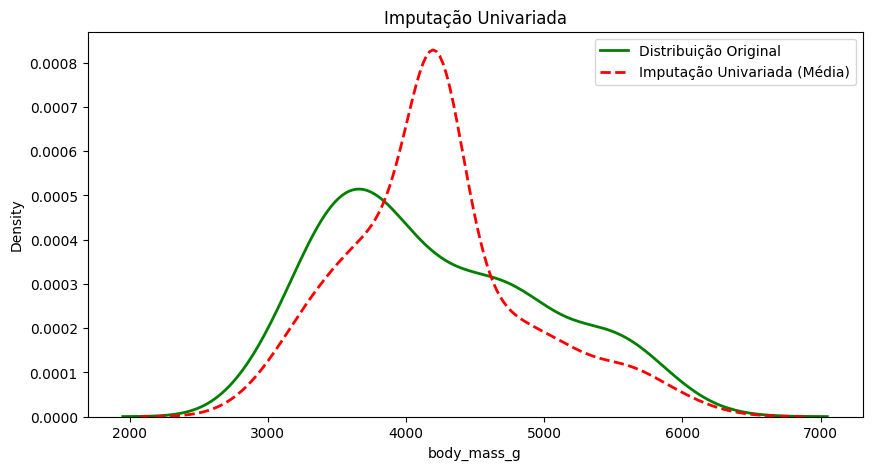

In [ ]:
from sklearn.impute import SimpleImputer

imputer_uni = SimpleImputer(strategy='mean')
df_uni = df_com_nulos.copy()
df_uni['body_mass_g'] = imputer_uni.fit_transform(df_uni[['body_mass_g']])

plt.figure(figsize=(10, 5))
sns.kdeplot(df['body_mass_g'], label='Distribuição Original', color='green', linewidth=2)
sns.kdeplot(df_uni['body_mass_g'], label='Imputação Univariada (Média)', color='red', linestyle='--', linewidth=2)
plt.title('Imputação Univariada')
plt.legend()
plt.show()

**O que o gráfico acima nos diz?**

Ao imputar pela média de forma isolada, nós dissemos matematicamente ao modelo que 30% da população de pinguins possui exatamente o mesmo peso. Criamos um pico anômalo e destruímos a variância.

Pior do que isso, nós ignoramos uma regra biológica óbvia: pinguins maiores (com nadadeiras maiores) costumam ser mais pesados. Nós imputamos um peso médio para pinguins gigantes e para pinguins minúsculos de forma idêntica.

## **3. Imputação Multivariada**

A imputação multivariada corrige o viés anterior ao tratar o conjunto de dados como um ecossistema. Em vez de olhar apenas para a coluna de peso, o algoritmo utiliza as demais variáveis disponíveis (como o tamanho da nadadeira e do bico) como preditoras para estimar de forma calculada qual seria o valor ausente daquele espécime específico.

O `IterativeImputer` do *scikit-learn* implementa essa abordagem. Ele cria internamente minúculos modelos de regressão, estimando cada variável incompleta a partir das outras de forma iterativa.

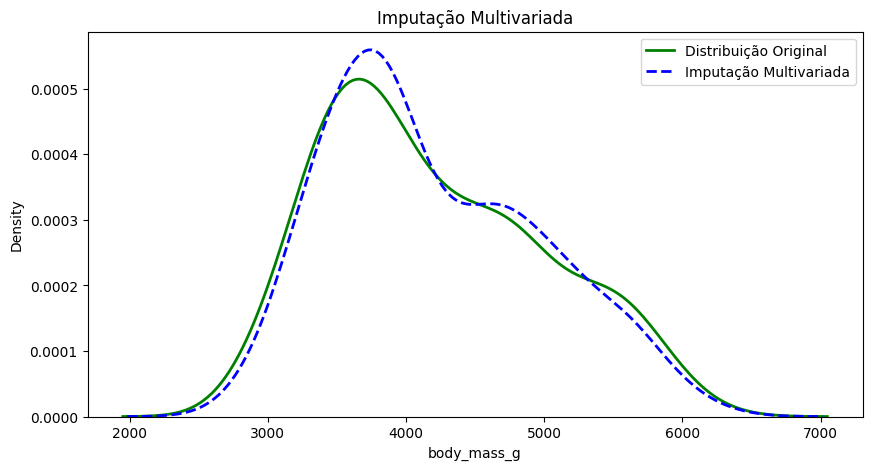

In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imputer_multi = IterativeImputer(random_state=42)
df_multi = pd.DataFrame(imputer_multi.fit_transform(df_com_nulos), columns=df_com_nulos.columns)

plt.figure(figsize=(10, 5))
sns.kdeplot(df['body_mass_g'], label='Distribuição Original', color='green', linewidth=2)
sns.kdeplot(df_multi['body_mass_g'], label='Imputação Multivariada', color='blue', linestyle='--', linewidth=2)
plt.title('Imputação Multivariada')
plt.legend()
plt.show()

## **4. Conclusão**

Observe como a curva azul (Multivariada) mimetiza a curva verde original com extrema fidelidade. O pico irreal e centralizado desapareceu.

Sempre que você se deparar com a necessidade de imputar dados faltantes em matrizes que contenham correlações lógicas (cenários MAR e MCAR), a imputação multivariada é muito mais sofisticada e recomendada, pois preserva as correlações naturais e a variância do conjunto de dados.